In [1]:
import pandas as pd
import numpy as np
import re
import string

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('vader_lexicon')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AMD\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\AMD\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\AMD\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [5]:
import pandas as pd

df = pd.read_csv("social_media_comments.csv")

df.head()

,Comment
0,This phone is amazing! I love the camera quality.
1,Worst customer service ever.
2,Battery life is excellent and performance is s...
3,The product is overpriced.
4,Absolutely fantastic experience.


In [13]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags
    text = re.sub(r'#', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Comment"] = df["Comment"].apply(clean_text)

print(df.head())

                                             Comment  \
0  This phone is amazing! I love the camera quality.   
1                       Worst customer service ever.   
2  Battery life is excellent and performance is s...   
3                         The product is overpriced.   
4                   Absolutely fantastic experience.   

                             Cleaned_Comment  
0          phone amazing love camera quality  
1                worst customer service ever  
2  battery life excellent performance smooth  
3                         product overpriced  
4            absolutely fantastic experience  


In [14]:
sia = SentimentIntensityAnalyzer()

def sentiment(text):

    score = sia.polarity_scores(str(text))

    if score['compound'] >= 0.05:
        return "Positive"

    elif score['compound'] <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned_Comment"].apply(sentiment)

print(df.head())

                                             Comment  \
0  This phone is amazing! I love the camera quality.   
1                       Worst customer service ever.   
2  Battery life is excellent and performance is s...   
3                         The product is overpriced.   
4                   Absolutely fantastic experience.   

                             Cleaned_Comment Sentiment  
0          phone amazing love camera quality  Positive  
1                worst customer service ever  Negative  
2  battery life excellent performance smooth  Positive  
3                         product overpriced   Neutral  
4            absolutely fantastic experience  Positive  


In [15]:
print(df.columns)

Index(['Comment', 'Cleaned_Comment', 'Sentiment'], dtype='object')


In [16]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    29
Negative    13
Neutral      8
Name: count, dtype: int64


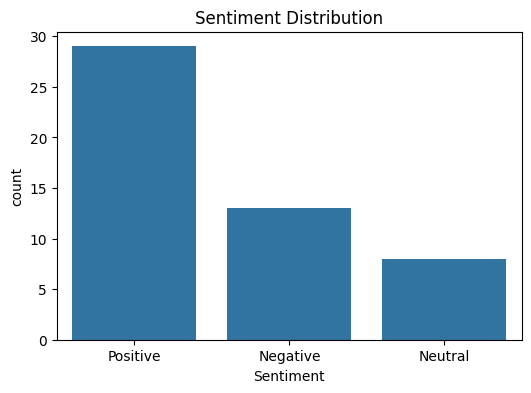

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sentiment")

plt.title("Sentiment Distribution")

plt.show()

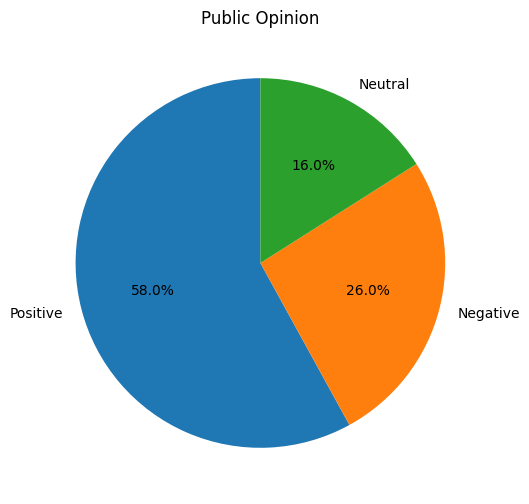

In [18]:
counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Public Opinion")

plt.show()

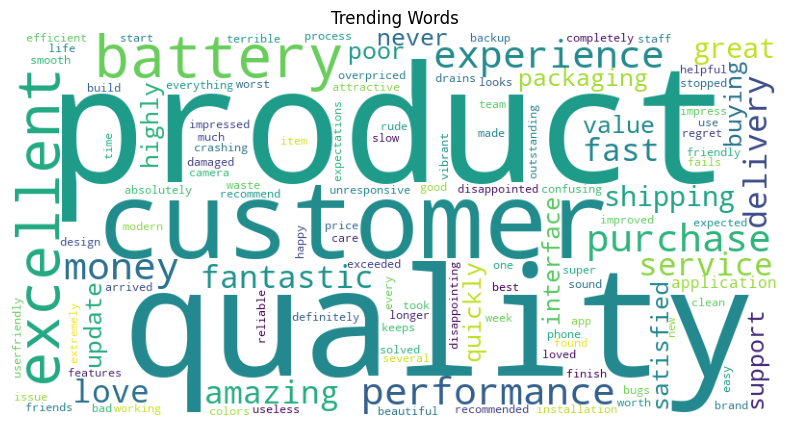

In [19]:
text = " ".join(df["Cleaned_Comment"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Trending Words")

plt.show()

In [20]:
vectorizer = CountVectorizer(stop_words="english")

X = vectorizer.fit_transform(df["Cleaned_Comment"])

word_counts = np.asarray(X.sum(axis=0)).flatten()

words = vectorizer.get_feature_names_out()

freq = pd.DataFrame({
    "Word": words,
    "Frequency": word_counts
})

freq = freq.sort_values(by="Frequency", ascending=False)

print(freq.head(10))

           Word  Frequency
74      product          7
76      quality          6
64        money          3
33    excellent          3
69  performance          3
36   experience          3
8       battery          3
22     customer          3
75     purchase          3
85     shipping          2
